# **1. Introduction to Data Preprocessing**

## **1.1 Basic Concepts: Why Data Preprocessing Matters**

The performance of a Machine Learning model depends heavily on the quality of the data used to train it. In data science, there is a famous principle called "Garbage In, Garbage Out" (GIGO). This means that if you feed an algorithm poor-quality, noisy, or "dirty" data, the resulting model will produce unreliable or "garbage" predictions, no matter how advanced the algorithm is.

Data Preprocessing is the process of transforming raw data into a clean and organized format that is suitable for machine learning models. It ensures that the model can learn patterns effectively without being misled by errors or inconsistencies.

## **1.2. Characteristics of Real-World Data**

In a classroom or competition, data is often "clean." However, in the real world, data is rarely ready for immediate use. You will often encounter:

- **Incomplete Data:** Missing values for certain attributes (e.g., a customer's age or phone number is missing).

- **Noisy/Dirty Data:** Containing errors, outliers, or values that don't make sense (e.g., a "Weight" of -50 kg).

- **Inconsistent Data:** Differences in naming conventions or formats (e.g., "U.S.A" in one row and "United States" in another, or different date formats).

## **1.3. Setup: Loading Datasets and Library Introduction**

Google Colab is an excellent environment for preprocessing because it comes with pre-installed data science libraries. The two most essential libraries are:

1. NumPy: Used for high-performance scientific computing and array manipulation.

2. Pandas: The primary tool for data manipulation and analysis (working with DataFrames).

Technical Implementation in Colab
First, we must import the libraries:

In [ ]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.2.2
NumPy version: 2.0.2


In Google Colab, you can load data from various sources. The most common way is using a URL or uploading a local CSV file. We will use the Titanic Dataset for this practicum.

In [ ]:
# Loading a CSV dataset from a URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display the first 5 rows of the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


To understand how "dirty" our data is, we use the following commands:

In [ ]:
# Check the structure, data types, and missing values
df.info()

# Summary statistics for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **2. Data Cleaning**

## **2.1. Handling Missing Values**

After inspecting the data in Chapter 1, you likely noticed that some columns have fewer entries than others. This indicates Missing Values. We have three main strategies to handle them:

1. Detection: Identifying which columns contain null values.

2. Deletion: Removing rows or columns with missing data (used if the missingness is high).

3. Imputation: Filling in the gaps with statistical values like Mean, Median, or Mode.

**Technical Implementation:**

In [ ]:
# 1. Detect missing values
print("Missing values per column:")
print(df.isnull().sum())

# 2. Imputation: Fill 'Age' with Median
# We use median because age often has outliers
df['Age'] = df['Age'].fillna(df['Age'].median())

# 3. Deletion: Drop 'Cabin' column
# We drop it because more than 70% of the data is missing
df.drop(columns=['Cabin'], inplace=True)

# 4. Fill 'Embarked' with Mode (the most frequent value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## **2.2. Handling Duplicates**

Duplicate data can bias your model by giving too much weight to specific observations. It is essential to identify and remove them to ensure data integrity.

**Technical Implementation:**

In [ ]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicates (if any)
df.drop_duplicates(inplace=True)

Number of duplicate rows: 0


## **2.3. Outlier Detection**

Outliers are data points that differ significantly from other observations. They can be caused by measurement errors or genuine extreme variations. In Python, we often use the Interquartile Range (IQR) method or visual tools like Boxplots.

**Technical Implementation:**

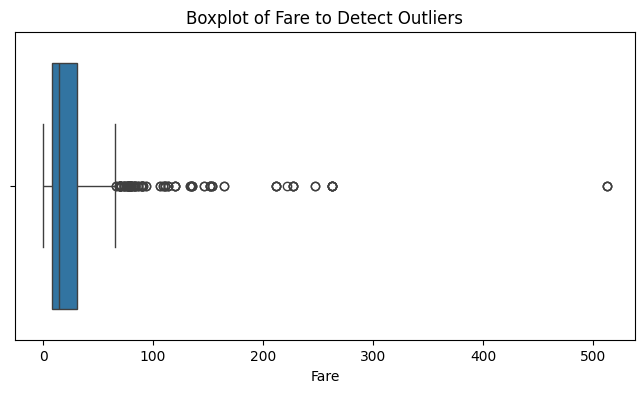

Number of outliers detected in 'Fare': 116


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing outliers in the 'Fare' column
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare to Detect Outliers')
plt.show()

# Statistical Detection using IQR
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]
print(f"Number of outliers detected in 'Fare': {len(outliers)}")

# **3. Encoding Categorical Data**

## **3.1. Types of Categorical Data**

Before encoding, we must distinguish between two types of categorical data:

- Nominal Data: Categories with no inherent order (e.g., Sex: Male, Female; Embarked: S, C, Q).

- Ordinal Data: Categories with a logical rank or order (e.g., Education: High School < Bachelor < Master; Satisfaction: Low < Medium < High).

## **3.2. Label Encoding**

Label Encoding assigns a unique integer to each category (e.g., 0, 1, 2). This is best suited for Ordinal Data because it preserves the order. If used on nominal data, the model might mistakenly think that a higher number is "better" or "larger."


**Technical Implementation:**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le = LabelEncoder()

# Example: Encoding 'Sex' (though it is nominal, often binary labels 0/1 are used)
df['Sex_Encoded'] = le.fit_transform(df['Sex'])

# Display mapping
print("Classes defined by LabelEncoder:", le.classes_)
df[['Sex', 'Sex_Encoded']].head()

Classes defined by LabelEncoder: ['female' 'male']


,Sex,Sex_Encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


## **3.3. One-Hot Encoding**

For Nominal Data, we use One-Hot Encoding. This technique creates new binary columns (0 or 1) for each category. This prevents the model from assuming a mathematical hierarchy between categories like "City" or "Color."

**Technical Implementation:**

In Pandas, we can easily do this using the `get_dummies()` function.

In [ ]:
# One-Hot Encoding for 'Embarked' column
# drop_first=True is used to avoid the "Dummy Variable Trap" (multicollinearity)
df_encoded = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Display the new columns
print("New columns after One-Hot Encoding:")
print(df_encoded.columns[-3:]) # Display the last 3 columns created
df_encoded.head()

New columns after One-Hot Encoding:
Index(['Sex_Encoded', 'Embarked_Q', 'Embarked_S'], dtype='object')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Sex_Encoded,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,1,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,0,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,0,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,1,False,True


# **4. Normalization & Feature Scaling**

## **4.1. The Importance of Scaling**

Imagine you are comparing two passengers:

- Passenger A: Age 20, Fare 10.
- Passenger B: Age 50, Fare 500.

If we don't scale, the algorithm will think the difference in **Fare** is much more important than the difference in **Age** simply because the numbers are larger. Scaling brings all features into a similar range so the model treats them fairly.

## **4.2. Min-Max Normalization**

Normalization scales the data into a fixed range, usually 0 to 1. This is very useful when you know the distribution of your data does not follow a Gaussian (Normal) distribution.

**Formula:**

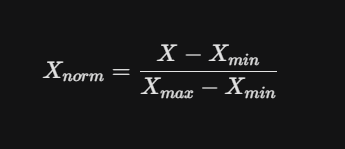

**Technical Implementation:**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# We scale 'Age' and 'Fare'
df_encoded[['Age', 'Fare']] = scaler.fit_transform(df_encoded[['Age', 'Fare']])

print("Data after Min-Max Normalization (Range 0-1):")
df_encoded[['Age', 'Fare']].describe()

Data after Min-Max Normalization (Range 0-1):


,Age,Fare
count,891.000000,891.000000
mean,0.363679,0.062858
std,0.163605,0.096995
min,0.000000,0.000000
25%,0.271174,0.015440
50%,0.346569,0.028213
75%,0.434531,0.060508
max,1.000000,1.000000


## **4.3  Standardization (Z-Score Scaling)**

Standardization transforms data so that it has a mean of 0 and a standard deviation of 1. This is the preferred method for many algorithms (like Linear Regression or Logistic Regression) that assume the data follows a Normal/Gaussian distribution.

**Formula:**

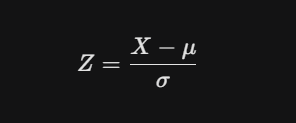

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
std_scaler = StandardScaler()

# Applying standardization
df_std = df_encoded.copy()
df_std[['Age', 'Fare']] = std_scaler.fit_transform(df_std[['Age', 'Fare']])

print("Data after Standardization (Mean ~0, Std ~1):")
print(f"Mean Age: {df_std['Age'].mean():.2f}")
print(f"Std Age: {df_std['Age'].std():.2f}")

NameError: name 'df_encoded' is not defined

## **4.4. When to use which?**

Normalization: Use when your data has a bounded range (like image pixels 0-255) or when you use algorithms like Neural Networks or KNN.

Standardization: Use when your data follows a Bell Curve (Normal distribution) or when you want to handle outliers more gracefully than Min-Max scaling.

# **CODELAB**

**Dataset:** Pima Indians Diabetes https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

**Focus:** Handling Hidden Nulls, Outliers, and Scaling

## **Task 1: Data Acquisition & Inspection**

Load the dataset and assign the appropriate column names. Display the first 10 rows to understand the initial structure.

- **Dataset URL**: https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

- **Columns**: `'Pregnancies',  'Glucose'`, `'BloodPressure'`, `'SkinThickness'`, `'Insulin'`, `'BMI'`, `'DiabetesPedigree'`, `'Age'`, `'Outcome'`

In [ ]:
# Hilmi Haidar Anwar
# 202310370311042

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# URL Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

# Load dataset
df = pd.read_csv(url, names=column_names)

# Menampilkan 10 baris pertama
print("Task 1: First 10 Rows")
df.head(10)

Task 1: First 10 Rows


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## **Task 2: Identifying Hidden Missing Values**

In this dataset, a value of 0 in certain columns is medically impossible and represents a Missing Value.

1. Convert all 0 values to NaN only for these columns: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`.

2. Count and display the total number of missing values per column.

In [ ]:
# Hilmi Haidar Anwar
# 202310370311042

cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Mengubah nilai 0 menjadi NaN (Not a Number)
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

# Menghitung dan menampilkan jumlah missing values per kolom
print("Task 2: Missing Values Count per Column")
print(df.isnull().sum())

Task 2: Missing Values Count per Column
Pregnancies           0
Glucose               5
BloodPressure        35
SkinThickness       227
Insulin             374
BMI                  11
DiabetesPedigree      0
Age                   0
Outcome               0
dtype: int64


## **Task 3: Handling Missing Values (Imputation)**

Now that you have identified the NaN values, you must fill them.

1. Perform Imputation using the Median value for all columns containing NaN.

2. Verify that there are no more missing values left in the dataframe.

In [ ]:
# Hilmi Haidar Anwar
# 202310370311042

# Mengisi nilai NaN dengan Median dari masing-masing kolom
for col in cols_to_fix:
    df[col] = df[col].fillna(df[col].median())

# Verifikasi apakah masih ada nilai yang kosong
print("Task 3: Verification (Should be all 0)")
print(df.isnull().sum())

Task 3: Verification (Should be all 0)
Pregnancies         0
Glucose             0
BloodPressure       0
SkinThickness       0
Insulin             0
BMI                 0
DiabetesPedigree    0
Age                 0
Outcome             0
dtype: int64


## **Task 4: Outlier Detection**

Extreme values in medical data (like Insulin levels) can skew model results.

1. Use a Boxplot to visualize the distribution of the Insulin column.

2. Briefly identify if there are many data points beyond the upper whisker.

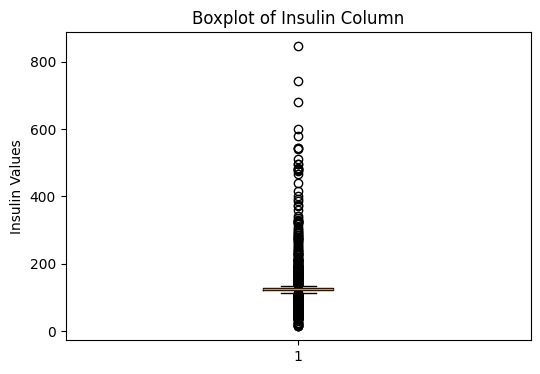

Analisis Task 4:
Berdasarkan boxplot, terlihat banyak titik-titik (lingkaran) di atas garis whisker atas.
Ini menunjukkan adanya banyak outliers atau nilai ekstrem pada data Insulin.


In [ ]:
# Hilmi Haidar Anwar
# 202310370311042
# Visualisasi dengan Boxplot untuk kolom Insulin
plt.figure(figsize=(6, 4))
plt.boxplot(df['Insulin'])
plt.title('Boxplot of Insulin Column')
plt.ylabel('Insulin Values')
plt.show()

# Analisis singkat:
print("Analisis Task 4:")
print("Berdasarkan boxplot, terlihat banyak titik-titik (lingkaran) di atas garis whisker atas.")
print("Ini menunjukkan adanya banyak outliers atau nilai ekstrem pada data Insulin.")

## **Task 5: Feature Scaling (Normalization)**

The features have very different ranges (e.g., `Age` vs `Insulin`). We need to normalize them.

1. Apply Min-Max Normalization to the entire dataset.

2. Ensure every value in the dataframe is now between 0 and 1.

In [ ]:
# Hilmi Haidar Anwar
# 202310370311042

# Inisialisasi Min-Max Scaler
scaler = MinMaxScaler()

# Melakukan normalisasi ke seluruh kolom dalam dataframe
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("Task 5: Scaled Data Preview")
df_scaled.head()

Task 5: Scaled Data Preview


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,0.352941,0.670968,0.489796,0.304348,0.133413,0.314928,0.234415,0.483333,1.0
1,0.058824,0.264516,0.428571,0.239130,0.133413,0.171779,0.116567,0.166667,0.0
2,0.470588,0.896774,0.408163,0.239130,0.133413,0.104294,0.253629,0.183333,1.0
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,0.0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,1.0


## **Final Submission Check**

Run the code below to ensure your data is ready for Machine Learning. All types should be numeric, and all values should be between 0 and 1.

In [ ]:
# FINAL CHECK
print("--- Data Info ---")
df.info()

print("\n--- Data Descriptive Statistics ---")
display(df.describe().loc[['min', 'max']])

print("\n--- Final Data Preview ---")
df.head()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pregnancies       768 non-null    int64  
 1   Glucose           768 non-null    float64
 2   BloodPressure     768 non-null    float64
 3   SkinThickness     768 non-null    float64
 4   Insulin           768 non-null    float64
 5   BMI               768 non-null    float64
 6   DiabetesPedigree  768 non-null    float64
 7   Age               768 non-null    int64  
 8   Outcome           768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB

--- Data Descriptive Statistics ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
min,0.0,44.0,24.0,7.0,14.0,18.2,0.078,21.0,0.0
max,17.0,199.0,122.0,99.0,846.0,67.1,2.420,81.0,1.0



--- Final Data Preview ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


# **ASSIGNMENTS**

**Dataset**
- **Topic:** Credit Card Approval

- **URL:** https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data

- **Notes:** This dataset also uses ? for missing values and contains a mix of continuous and categorical attributes.

- **Column Names:** `'A1'`, `'A2'`, `'A3'`, `'A4'`, `'A5'`, `'A6'`, `'A7'`, `'A8'`, `'A9'`, `'A10'`, `'A11'`, `'A12'`, `'A13'`, `'A14'`, `'A15'`, `'A16'`

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## **Task 1: Data Acquisition & Initial Cleaning**

Load your respective dataset. Ensure that the symbol ? is correctly recognized as a Missing Value (NaN) during or after loading. Display the first 10 rows and the data types of each column.

In [ ]:
# Hilmi Haidar Anwar
# 202310370311042

# URL dan colum name
url_b = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
columns_b = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16']

# "?" = Nan
df = pd.read_csv(url_b, header=None, names=columns_b, na_values="?")

# Data type
print("--- 10 Baris Pertama Dataset B ---")
display(df.head(10))
print("\n--- Tipe Data Setiap Kolom ---")
print(df.dtypes)

--- 10 Baris Pertama Dataset B ---


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.250,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.040,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.500,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.750,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.710,t,f,0,f,s,120.0,0,+
5,b,32.08,4.000,u,g,m,v,2.500,t,f,0,t,g,360.0,0,+
6,b,33.17,1.040,u,g,r,h,6.500,t,f,0,t,g,164.0,31285,+
7,a,22.92,11.585,u,g,cc,v,0.040,t,f,0,f,g,80.0,1349,+
8,b,54.42,0.500,y,p,k,h,3.960,t,f,0,f,g,180.0,314,+
9,b,42.50,4.915,y,p,w,v,3.165,t,f,0,t,g,52.0,1442,+



--- Tipe Data Setiap Kolom ---
A1      object
A2     float64
A3     float64
A4      object
A5      object
A6      object
A7      object
A8     float64
A9      object
A10     object
A11      int64
A12     object
A13     object
A14    float64
A15      int64
A16     object
dtype: object


## **Task 2: Advanced Imputation**

1. Identify which columns are numerical and which are categorical.

2. For Numerical columns: Fill missing values with the Median.

3. For Categorical columns: Fill missing values with the Mode (most frequent value).

In [ ]:
# Hilmi Haidar Anwar
# 202310370311042

# Num and Categoric
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Isi Median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Isi Modus
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Jumlah missing values setelah imputasi:")
print(df.isnull().sum())

Jumlah missing values setelah imputasi:
A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
A16    0
dtype: int64


## **Task 3: Outlier Handling**


1. Choose one continuous numerical column from your dataset (e.g., pulse for Dataset A or A2 for Dataset B).

2. Visualize the distribution using a Boxplot.

3. Identify if outliers exist.

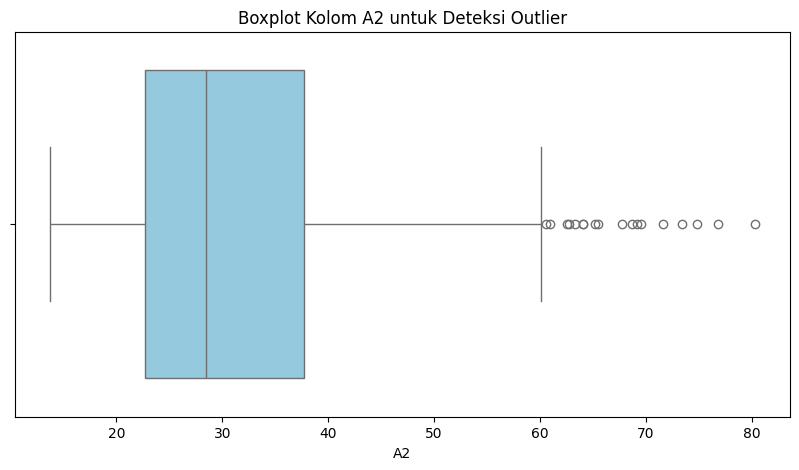

Batas bawah: 0.11375000000001023, Batas atas: 60.26374999999999
Ditemukan sebanyak 18 data outlier pada kolom A2.


In [ ]:
# Hilmi Haidar Anwar
# 202310370311042

# kontinu A2 and Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['A2'], color='skyblue')
plt.title('Boxplot Kolom A2 untuk Deteksi Outlier')
plt.show()

# Check Outlier
Q1 = df['A2'].quantile(0.25)
Q3 = df['A2'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['A2'] < lower_limit) | (df['A2'] > upper_limit)]
print(f"Batas bawah: {lower_limit}, Batas atas: {upper_limit}")
print(f"Ditemukan sebanyak {len(outliers)} data outlier pada kolom A2.")

## **Task 4: Categorical Encoding**


Machine learning models require numerical input.

1. Pick one categorical column.

2. Apply Label Encoding if the data is ordinal, or One-Hot Encoding if it is nominal.

In [ ]:
# Hilmi Haidar Anwar
# 202310370311042

# Kolom A1 and One hot Encoding
df = pd.get_dummies(df, columns=['A1'], prefix='A1')

# Encoding another column A9
le = LabelEncoder()
df['A9'] = le.fit_transform(df['A9'].astype(str))

print("Kolom setelah Encoding (5 baris pertama):")
display(df.head())

Kolom setelah Encoding (5 baris pertama):


,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16,A1_a,A1_b
0,30.83,0.000,u,g,w,v,1.25,1,t,1,f,g,202.0,0,+,False,True
1,58.67,4.460,u,g,q,h,3.04,1,t,6,f,g,43.0,560,+,True,False
2,24.50,0.500,u,g,q,h,1.50,1,f,0,f,g,280.0,824,+,True,False
3,27.83,1.540,u,g,w,v,3.75,1,t,5,t,g,100.0,3,+,False,True
4,20.17,5.625,u,g,w,v,1.71,1,f,0,f,s,120.0,0,+,False,True


## **Task 5: Normalization**


Apply Min-Max Normalization to all numerical columns so that the values are constrained between 0 and 1.

In [ ]:
# Hilmi Haidar Anwar
# 202310370311042

# Scaler
scaler = MinMaxScaler()

# Mnumeric Column Normalization
numeric_features = df.select_dtypes(include=[np.number]).columns
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# Final Check
print("--- Final Data Preview (Setelah Normalisasi) ---")
display(df.head())
print("\n--- Statistik Deskriptif (Min & Max) ---")
display(df[numeric_features].describe().loc[['min', 'max']])

--- Final Data Preview (Setelah Normalisasi) ---


,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16,A1_a,A1_b
0,0.256842,0.000000,u,g,w,v,0.043860,1.0,t,0.014925,f,g,0.1010,0.00000,+,False,True
1,0.675489,0.159286,u,g,q,h,0.106667,1.0,t,0.089552,f,g,0.0215,0.00560,+,True,False
2,0.161654,0.017857,u,g,q,h,0.052632,1.0,f,0.000000,f,g,0.1400,0.00824,+,True,False
3,0.211729,0.055000,u,g,w,v,0.131579,1.0,t,0.074627,t,g,0.0500,0.00003,+,False,True
4,0.096541,0.200893,u,g,w,v,0.060000,1.0,f,0.000000,f,s,0.0600,0.00000,+,False,True



--- Statistik Deskriptif (Min & Max) ---


,A2,A3,A8,A9,A11,A14,A15
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0
